In [3]:
import os
from pathlib import Path


import sys
from pathlib import Path
print("cwd:", os.getcwd())

print("cwd contents:", [p.name for p in Path.cwd().iterdir()])

sys.path.insert(0, str(Path.cwd() / "src"))
os.chdir(Path.cwd().parent)   # move from .../Lux/notebooks -> .../Lux


cwd: /home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code
cwd contents: ['Lux', 'Data']


In [4]:
import jax.numpy as jnp
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
from astropy.io import fits
import tqdm

from matplotlib import rc
import matplotlib.pyplot as plt
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
import cmasher as cm

import load_data as ld
import optimise as opt
import scatters as opt_sc
import init_latents as il
import kfold_cv as kf

In [8]:
file_name = '-train-rgs-galah'
spectra_dir_path = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Data/'
file_path = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Data/master-APOGEE-giants-GALAH.fits'
spectra_data, label_data = ld.load_data_galah(spectra_dir_path, file_path, file_name)

/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Data/spectra_data-train-rgs-galah.dat
File already exists. Loading spectra data


22it [00:03,  6.04it/s]


Loaded data successfully


In [19]:
print(type(label_data["label_names"]))
print(label_data)

<class 'list'>
{'ids': chararray(['2M00033670-7250054', '2M00050927-5144526',
           '2M00053358-5122465', ..., '2M16491028-2452471',
           '2M16491201-1957502', '2M16491276-2513431'],
          shape=(4999,), dtype='<U18'), 'snr': array([506.53516 , 169.70769 ,  61.690456, ..., 279.32068 , 117.11388 ,
       463.39362 ], shape=(4999,), dtype='>f4'), 'label_names': ['teff', 'logg', 'fe_h', 'Li_fe', 'Na_fe', 'O_fe', 'Mg_fe', 'Y_fe', 'Ce_fe', 'Ba_fe', 'Eu_fe'], 'labels': Array([[ 4.95447656e+03,  3.17336106e+00, -2.36254692e-01, ...,
        -1.82690009e-01, -5.78765106e-02,  1.44312553e-01],
       [ 4.66306006e+03,  2.48093534e+00,  4.70552444e-02, ...,
        -8.33700001e-02,  2.99331741e-01,  3.82506180e-02],
       [ 5.18926025e+03,  2.47480655e+00, -8.81706238e-01, ...,
        -1.39946505e-01,  6.74541550e-01,  1.44312553e-01],
       ...,
       [ 4.54876074e+03,  2.25840569e+00, -7.21740723e-03, ...,
        -2.61144012e-01,  2.61172371e-01, -6.04451370e-02],
       [ 

In [ ]:


labels = label_data["labels"]
names = label_data["label_names"]
labels_err = label_data["labels_err"]
err_names = label_data["label_names_err"]

# understanding what labels looks like -- labels is a 4999 by 11 2d array. That is 4999 stars, and 11 labels, like t_eff etc
#labels[k, :] prints all 11 labels for star k 
#labels[:, j] label j for all 4999 stars
#We need fe_h, ehich is label index 2 -- i_feh. so to refer to all the fe_h data, we do labels[:, i_feh]

i_feh = names.index("fe_h")
feh   = labels[:, i_feh]

i_feh_err = err_names.index("e_fe_h")
feh_err = labels[:, i_feh_err]

new_names = list(names)
for name in range(i_feh+1, len(new_names)):
    if new_names[name].endswith("_fe"):
        new_names[name] = new_names[name].replace("_fe", "_h")


new_err_names = list(err_names)
for name in range(i_feh+1, len(new_names)):
    if new_err_names[name].endswith("_fe"):
        new_err_names[name] = new_err_names[name].replace("_fe", "_h")



labels_h = labels.at[:, i_feh+1:].set(labels[:, i_feh+1:] + feh[:, None])
err_new = labels_err.at[:, i_feh_err+1:].set(jnp.sqrt(labels_err[:, i_feh_err+1:]**2 + feh_err[:, None]**2))
#jax arrays -- .at method https://docs.jax.dev/en/latest/_autosummary/jax.Array.at.html#jax.Array.at  basically creates a modified version of the inital variable labels_err. .set describes what the new value will be.
#so err_new is a copy of labels_err with new values at every index after e_fe_h (e_fe_h + 1)




label_data_h = dict(label_data)
label_data_h["label_names"] = new_names
label_data_h["label_names_err"] = new_err_names

label_data_h["labels"] = labels_h
label_data_h["labels_err"] = err_new




print(label_data_h)


{'ids': chararray(['2M00033670-7250054', '2M00050927-5144526',
           '2M00053358-5122465', ..., '2M16491028-2452471',
           '2M16491201-1957502', '2M16491276-2513431'],
          shape=(4999,), dtype='<U18'), 'snr': array([506.53516 , 169.70769 ,  61.690456, ..., 279.32068 , 117.11388 ,
       463.39362 ], shape=(4999,), dtype='>f4'), 'label_names': ['teff', 'logg', 'fe_h', 'Li_h', 'Na_h', 'O_h', 'Mg_h', 'Y_h', 'Ce_h', 'Ba_h', 'Eu_h'], 'labels': Array([[ 4.95447656e+03,  3.17336106e+00, -2.36254692e-01, ...,
        -4.18944702e-01, -2.94131203e-01, -9.19421387e-02],
       [ 4.66306006e+03,  2.48093534e+00,  4.70552444e-02, ...,
        -3.63147557e-02,  3.46386986e-01,  8.53058624e-02],
       [ 5.18926025e+03,  2.47480655e+00, -8.81706238e-01, ...,
        -1.02165274e+00, -2.07164688e-01, -7.37393684e-01],
       ...,
       [ 4.54876074e+03,  2.25840569e+00, -7.21740723e-03, ...,
        -2.68361419e-01,  2.53954964e-01, -6.76625443e-02],
       [ 4.25336279e+03,  1.1477

NameError: name 'label_data_h' is not defined

In [25]:
n = 4000

train_ID = label_data['ids'][:n]
train_flux = spectra_data['fluxes'][:n]
train_flux_err = spectra_data['fluxes_err'][:n]
train_flux_ivar = spectra_data['fluxes_ivars'][:n]
train_label = label_data['labels'][:n]
train_label_err = label_data['labels_err'][:n]
train_label_ivar = label_data['labels_ivars'][:n]

test_ID = label_data['ids'][n:]
test_flux = spectra_data['fluxes'][n:]
test_flux_err = spectra_data['fluxes_err'][n:]
test_flux_ivar = spectra_data['fluxes_ivars'][n:]
test_label = label_data['labels'][n:]
test_label_err = label_data['labels_err'][n:]
test_label_ivar = label_data['labels_ivars'][n:]

In [10]:
n = 4000

train_ID = label_data_h['ids'][:n]
train_flux = spectra_data['fluxes'][:n]
train_flux_err = spectra_data['fluxes_err'][:n]
train_flux_ivar = spectra_data['fluxes_ivars'][:n]
train_label = label_data_h['labels'][:n]
train_label_err = label_data_h['labels_err'][:n]
train_label_ivar = label_data_h['labels_ivars'][:n]

test_ID = label_data_h['ids'][n:]
test_flux = spectra_data['fluxes'][n:]
test_flux_err = spectra_data['fluxes_err'][n:]
test_flux_ivar = spectra_data['fluxes_ivars'][n:]
test_label = label_data_h['labels'][n:]
test_label_err = label_data_h['labels_err'][n:]
test_label_ivar = label_data_h['labels_ivars'][n:]

In [11]:
P = 49
alphas, betas, zetas = il.initialise_alphas_betas_zetas(train_label, train_flux, P)
alphas.shape, betas.shape, zetas.shape

((11, 49), (8575, 49), (4000, 49))

In [12]:
niter = 5
alphas_iter = jnp.zeros((niter,) + alphas.shape)
betas_iter = jnp.zeros((niter,) + betas.shape)
zetas_iter = jnp.zeros((niter,) + zetas.shape)
diff_chi2_iter = jnp.zeros((niter))
chi2_iter = jnp.zeros((niter))

omega = 1.
for iter in tqdm.tqdm_notebook(range(niter)):
    alphas, betas, zetas, diff_chi2, chi2 = opt.run_agenda(alphas, betas, zetas, train_label, train_label_err, train_flux, train_flux_err, omega)
    alphas_iter = alphas_iter.at[iter].set(alphas)
    betas_iter = betas_iter.at[iter].set(betas)
    zetas_iter = zetas_iter.at[iter].set(zetas)
    diff_chi2_iter = diff_chi2_iter.at[iter].set(diff_chi2)
    chi2_iter = chi2_iter.at[iter].set(chi2)

/tmp/ipykernel_4147343/141839097.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for iter in tqdm.tqdm_notebook(range(niter)):


  0%|          | 0/5 [00:00<?, ?it/s]

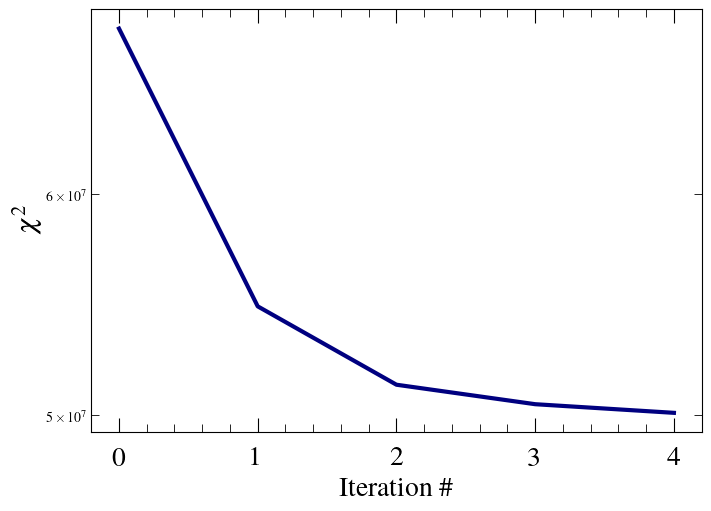

In [14]:
name = '_P49_omega1-train-giantsgalah'
savepath = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Trainh/'

np.save(savepath+'alphas_giants'+str(name), alphas_iter)
np.save(savepath+'betas_giants'+str(name), betas_iter)
np.save(savepath+'diff_chi2_giants'+str(name), diff_chi2_iter)
np.save(savepath+'chi2_giants'+str(name), chi2_iter)
np.save(savepath+'zetas_train_giants'+str(name), zetas_iter)

plt.figure(figsize=(7,5), constrained_layout=True)

plt.plot(chi2_iter, color='navy', lw=3)
plt.ylabel('$\chi^{2}$', fontsize=20)
plt.xlabel('Iteration $\#$', fontsize=20)
plt.yscale('log')
plt.tick_params(labelsize=25,direction='in',top=True,right=True,length=6,pad=10)
plt.tick_params(which='major',labelsize=20,direction='in',top=True,right=True,length=10)
plt.tick_params(which='minor', length=6, direction='in',top=True,right=True)
plt.minorticks_on()

plt.savefig('/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Plots/CV-trainhydrogen-galahstars-lux.pdf',dpi=200, bbox_inches = 'tight')

In [15]:
ln_noise_fluxes_init = jnp.full(train_flux.shape[1], -8.0)
l2_reg_strength = 1000
omega=1.

In [16]:
name = '_P49_omega1-train-giantsgalah'
savepath = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Trainh/'

alphas_iter = np.load(savepath+'alphas_giants'+str(name)+'.npy', allow_pickle=True)
betas_iter = np.load(savepath+'betas_giants'+str(name)+'.npy', allow_pickle=True)
zetas_iter = np.load(savepath+'zetas_train_giants'+str(name)+'.npy', allow_pickle=True)

alphas = alphas_iter[-1, :, :]
betas = betas_iter[-1, :, :]
zetas = zetas_iter[-1, :, :]


In [17]:
# run optimisation routine with noise in the flux
betas_updated, zetas_updated, ln_noise_fluxes_updated, nll_updated = opt_sc.run_agenda(alphas, betas, zetas, train_label, train_label_ivar, train_flux, train_flux_ivar,\
                                            ln_noise_fluxes_init, l2_reg_strength, omega)


In [20]:
name = '_P49_L2regstrength1000_omega1-train-giantsgalah'
savepath = '/home/finrenton/Documents/University/YR4Sem2/SeniorHonours/Code/Lux/Trainh/'

np.save(savepath+'alphas_giants-withscatters'+str(name), alphas)
np.save(savepath+'betas_giants-withscatters'+str(name), betas_updated)
np.save(savepath+'zetas_train_giants-withscatters'+str(name), zetas_updated)
np.save(savepath+'noise_fluxes_train_giants-withscatters'+str(name), jnp.exp(ln_noise_fluxes_updated))
np.save(savepath+'nll_train_giants-withscatters'+str(name),nll_updated)

In [21]:
l = zetas_updated @ alphas.T
s = zetas_updated @ betas_updated.T